# BiLSTM (Approach 3 of 5, the first neural model)

A bidirectional LSTM over learned word embeddings. Unlike the TF-IDF baselines
(`baselines.ipynb`), this can actually make use of word order — which matters because
EDA finding #10 showed all three classes share the same core vocabulary, so whatever
separates them has to be in order and context. Kept small given the CPU-only budget:
`max_seq_len=32` (finding #4 put the 95th-percentile tweet length at 24 words),
single-layer BiLSTM, hidden size 128.


In [1]:
import sys
sys.path.append('../src')
import pandas as pd
import torch

from preprocessing import LABEL_TO_IDX, CLASS_NAMES
from text_dataset import Vocab, TweetDataset
from models import BiLSTMClassifier
from train_utils import compute_class_weights, train_model, predict
from eval_utils import evaluate, set_seed

set_seed(42)
torch.set_num_threads(4)
device = 'cpu'

train_df = pd.read_csv('../data/processed/train_split.csv')
val_df = pd.read_csv('../data/processed/val_split.csv')

train_texts = train_df['clean_text'].tolist()
val_texts = val_df['clean_text'].tolist()
train_labels = train_df['label'].map(LABEL_TO_IDX).tolist()
val_labels = val_df['label'].map(LABEL_TO_IDX).tolist()

print(len(train_texts), len(val_texts))


8205 1449


## Build vocabulary (train-only, to avoid leakage) and encode sequences

In [2]:
MAX_LEN = 32
vocab = Vocab(train_texts, min_freq=2, max_size=20000)
print('Vocab size:', len(vocab))

train_ds = TweetDataset(train_texts, train_labels, vocab, max_len=MAX_LEN)
val_ds = TweetDataset(val_texts, val_labels, vocab, max_len=MAX_LEN)
class_weights = compute_class_weights(train_labels)
print('Class weights (Neg, Neutral, Pos order per LABEL_TO_IDX):', class_weights)


Vocab size: 6991
Class weights (Neg, Neutral, Pos order per LABEL_TO_IDX): tensor([3.1401, 0.6862, 0.8169])


## Train
Adam, class-weighted cross-entropy, early stopping on validation macro-F1 (patience 3).

In [3]:
model = BiLSTMClassifier(vocab_size=len(vocab), embed_dim=128, hidden_dim=128, n_classes=3, pad_idx=vocab.stoi['<pad>'])
model, history = train_model(
    model, train_ds, val_ds, class_weights,
    epochs=12, batch_size=64, lr=1e-3, patience=3, device=device,
)


Epoch 1/12 | train_loss=1.0192 val_loss=0.9323 val_macro_f1=0.5122 (43.4s)


Epoch 2/12 | train_loss=0.8677 val_loss=0.8926 val_macro_f1=0.5639 (45.0s)


Epoch 3/12 | train_loss=0.7528 val_loss=0.8655 val_macro_f1=0.5575 (44.1s)


Epoch 4/12 | train_loss=0.6435 val_loss=0.8841 val_macro_f1=0.6127 (46.0s)


Epoch 5/12 | train_loss=0.5157 val_loss=0.9659 val_macro_f1=0.5924 (43.2s)


Epoch 6/12 | train_loss=0.4280 val_loss=1.0655 val_macro_f1=0.6255 (42.5s)


Epoch 7/12 | train_loss=0.3088 val_loss=1.1394 val_macro_f1=0.6314 (40.3s)


Epoch 8/12 | train_loss=0.2460 val_loss=1.2373 val_macro_f1=0.6163 (44.5s)


Epoch 9/12 | train_loss=0.1752 val_loss=1.5434 val_macro_f1=0.6086 (42.9s)


Epoch 10/12 | train_loss=0.1305 val_loss=1.4855 val_macro_f1=0.6184 (43.6s)
Early stopping at epoch 10 (no improvement for 3 epochs).


## Training curves

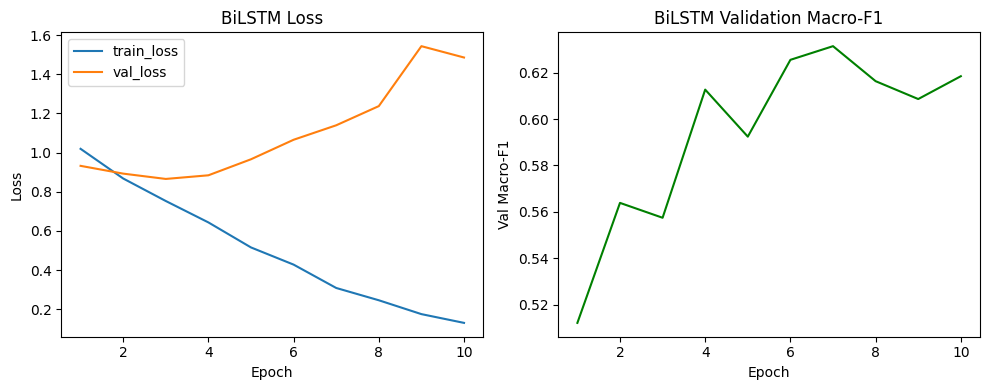

In [4]:
import matplotlib.pyplot as plt
hist_df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(hist_df['epoch'], hist_df['train_loss'], label='train_loss')
axes[0].plot(hist_df['epoch'], hist_df['val_loss'], label='val_loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].set_title('BiLSTM Loss')
axes[1].plot(hist_df['epoch'], hist_df['val_macro_f1'], color='green')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val Macro-F1'); axes[1].set_title('BiLSTM Validation Macro-F1')
fig.tight_layout()
fig.savefig('../figures/bilstm_training_curves.png', dpi=150)
plt.show()


## Evaluate on validation set

In [5]:
val_preds = predict(model, val_ds, device=device)
result = evaluate(val_labels, val_preds, 'BiLSTM')



=== BiLSTM ===
Macro-F1: 0.6314  Weighted-F1: 0.7042  Accuracy: 0.6984
              precision    recall  f1-score   support

    Negative       0.38      0.49      0.42       154
     Neutral       0.81      0.73      0.77       704
    Positive       0.69      0.72      0.70       591

    accuracy                           0.70      1449
   macro avg       0.62      0.64      0.63      1449
weighted avg       0.71      0.70      0.70      1449



## ROC and Precision-Recall curves
One-vs-rest curves from the model's own softmax probabilities. Worth having given the
class imbalance (finding #1) — a confusion matrix alone doesn't show how well-separated
the predicted probabilities actually are.


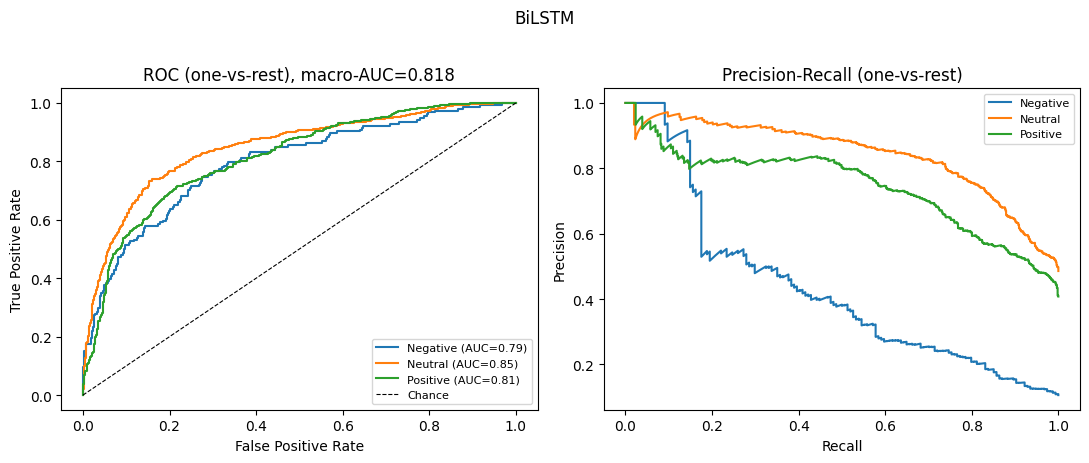

BiLSTM macro-AUC: 0.8179


In [6]:
from train_utils import predict_proba
from eval_utils import plot_roc_pr

val_proba = predict_proba(model, val_ds, device=device)
macro_auc = plot_roc_pr(val_labels, val_proba, 'BiLSTM')
print('BiLSTM macro-AUC:', round(macro_auc, 4))


## Summary
Results in `reports/results/BiLSTM.json`, confusion matrix in
`figures/cm_bilstm.png`, training curves in `figures/bilstm_training_curves.png`, ROC/PR
curves in `figures/roc_pr_bilstm.png`.
